# Laboratorio 1 — Series de Tiempo
## 1. Análisis Exploratorio de Datos (EDA)
**CC3084 – Data Science · UVG · Semestre II 2026**

Datos: ingreso mensual de viajeros internacionales a Guatemala (ene-2009 a jun-2026).
*Uso exclusivamente académico; no son cifras oficiales del INGUAT ni del IGM.*

Este cuaderno cubre el inciso **1** del laboratorio:
comportamiento temporal, países, regiones, vías y fronteras, valores faltantes/duplicados/atípicos,
y estadísticas descriptivas con su interpretación.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# rutas del proyecto
ROOT = Path.cwd().parents[1] if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.append(str(ROOT / '01_limpieza_eda' / 'src'))
import config
config.aplicar_estilo()
MILES = FuncFormatter(config.miles)
P = config.PALETTE

# Cargar datos limpios (generados por src/limpieza.py)
df = pd.read_csv(config.CLEAN_CSV, parse_dates=['fecha'])
print('Registros:', len(df), '| Columnas:', df.shape[1])
df.head(3)

Registros: 161015 | Columnas: 14


,Año,Mes cod,Mes,Vía,Frontera,País,Región,Región dos,Regiones OMT,MCEO,Agrupación Residencia,Tipo de Viajero,Viajero,fecha
0,2009,1,Ene,Aérea,01 La Aurora,Albania,OTROS EUROPEOS,Europa,EUROPA MERIDIONAL,08 OTROS,Europa,Turista,1.0,2009-01-01
1,2009,1,Ene,Aérea,01 La Aurora,Alemania,EUROPA,Europa,EUROPA OCCIDENTAL,04 EUROPA,Europa,Turista,716.0,2009-01-01
2,2009,1,Ene,Aérea,01 La Aurora,Angola,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA CENTRAL,08 OTROS,Resto del Mundo,Turista,4.0,2009-01-01


### 1.1 Estructura y calidad del conjunto de datos

In [2]:
print('Rango temporal:', df['fecha'].min().date(), '→', df['fecha'].max().date())
print('Meses únicos :', df['fecha'].nunique(), '(esperado 210, sin huecos)')
print()
print('Tipos de dato:')
print(df.dtypes)

Rango temporal: 2009-01-01 → 2026-06-01
Meses únicos : 210 (esperado 210, sin huecos)

Tipos de dato:
Año                               int64
Mes cod                           int64
Mes                                 str
Vía                                 str
Frontera                            str
País                                str
Región                              str
Región dos                          str
Regiones OMT                        str
MCEO                                str
Agrupación Residencia               str
Tipo de Viajero                     str
Viajero                         float64
fecha                    datetime64[us]
dtype: object


In [3]:
# Valores faltantes y duplicados (inciso 1.e)
resumen_calidad = pd.DataFrame({
    'nulos': df.isna().sum(),
    '%_nulos': (df.isna().mean()*100).round(2),
})
print('Filas duplicadas (completas):', df.duplicated().sum())
print('Registros con Viajero = 0    :', int((df['Viajero']==0).sum()))
print('Registros con Viajero < 0    :', int((df['Viajero']<0).sum()))
resumen_calidad

Filas duplicadas (completas): 0
Registros con Viajero = 0    : 54
Registros con Viajero < 0    : 0


,nulos,%_nulos
Año,0,0.0
Mes cod,0,0.0
Mes,0,0.0
Vía,0,0.0
Frontera,0,0.0
País,0,0.0
Región,0,0.0
Región dos,0,0.0
Regiones OMT,0,0.0
MCEO,0,0.0


**Interpretación (calidad).** El conjunto está prácticamente completo: **210 meses consecutivos sin huecos**,
**sin valores nulos** y **sin filas duplicadas**. En la limpieza previa se eliminaron 21 filas con categorías
inválidas en `Región dos` (`"0"` y `"Cruceros"`). La variable `Viajero` **no es entera**: contiene valores
fraccionarios (p. ej. 38.89), lo que indica que algunos conteos fueron **estimados/prorrateados**; hay además
54 registros en 0. Ninguno es negativo.

In [4]:
# Estadísticas descriptivas de la variable objetivo (inciso 1.f)
desc = df['Viajero'].describe(percentiles=[.25,.5,.75,.9,.99]).round(2)
print(desc.to_string())

count    161015.00
mean        324.57
std        2387.70
min           0.00
25%           2.00
50%           7.00
75%          38.82
90%         260.00
99%        6109.68
max       92336.04


### 1.2 Análisis de valores atípicos (inciso 1.e)

/tmp/ipykernel_4717/2558014715.py:6: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(df['Viajero'], vert=True, widths=0.5,


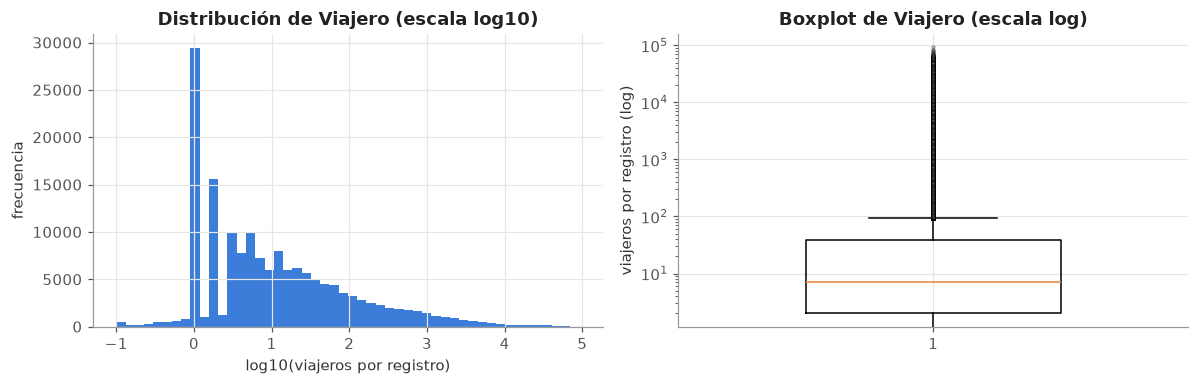

Registros >  P99 (6110): 1611


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].hist(np.log10(df['Viajero'].clip(lower=0.1)), bins=50, color=P['azul'])
ax[0].set_title('Distribución de Viajero (escala log10)')
ax[0].set_xlabel('log10(viajeros por registro)'); ax[0].set_ylabel('frecuencia')

ax[1].boxplot(df['Viajero'], vert=True, widths=0.5,
              flierprops=dict(marker='o', markersize=2, alpha=0.3, markerfacecolor=P['gris']))
ax[1].set_yscale('log'); ax[1].set_title('Boxplot de Viajero (escala log)')
ax[1].set_ylabel('viajeros por registro (log)')
plt.tight_layout(); plt.savefig(config.FIG_DIR / 'eda_distribucion_viajero.png'); plt.show()

print('Registros >  P99 ({:.0f}): {}'.format(df['Viajero'].quantile(.99),
      int((df['Viajero'] > df['Viajero'].quantile(.99)).sum())))

**Interpretación (atípicos).** La variable es **fuertemente asimétrica a la derecha**: la mediana es de ~7 viajeros
por registro, pero el máximo supera los 92,000. Estos "atípicos" **no son errores**: corresponden a combinaciones
de alto volumen (p. ej. terrestre desde El Salvador por La Aurora/Valle Nuevo, o meses pico). Por eso **no se eliminan**;
al agregar por mes para construir las series, el efecto de la cola se integra de forma natural.

### 1.3 Comportamiento temporal del número de viajeros (inciso 1.a)

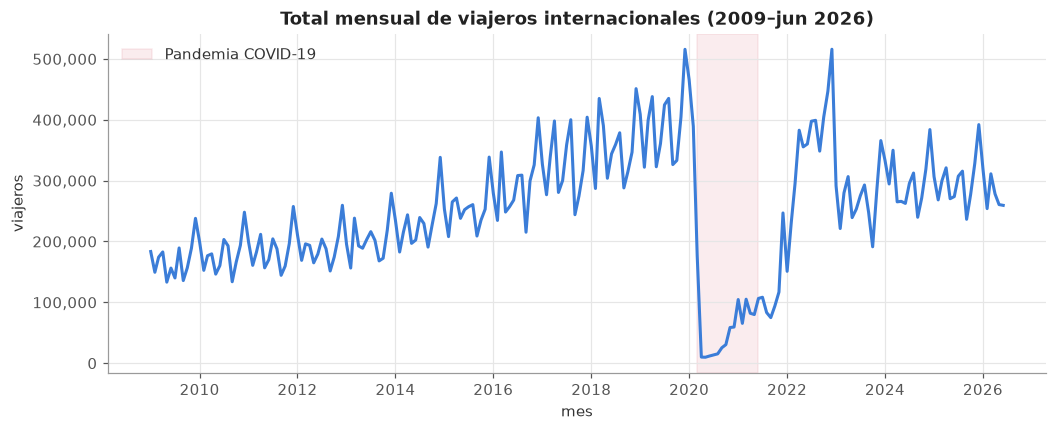

In [6]:
total_mes = df.groupby('fecha')['Viajero'].sum()
total_anio = df.groupby('Año')['Viajero'].sum()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(total_mes.index, total_mes.values, color=P['azul'])
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-06-01'),
           color=P['rojo'], alpha=0.10, label='Pandemia COVID-19')
ax.yaxis.set_major_formatter(MILES)
ax.set_title('Total mensual de viajeros internacionales (2009–jun 2026)')
ax.set_xlabel('mes'); ax.set_ylabel('viajeros'); ax.legend(loc='upper left')
plt.savefig(config.FIG_DIR / 'eda_total_mensual.png'); plt.show()

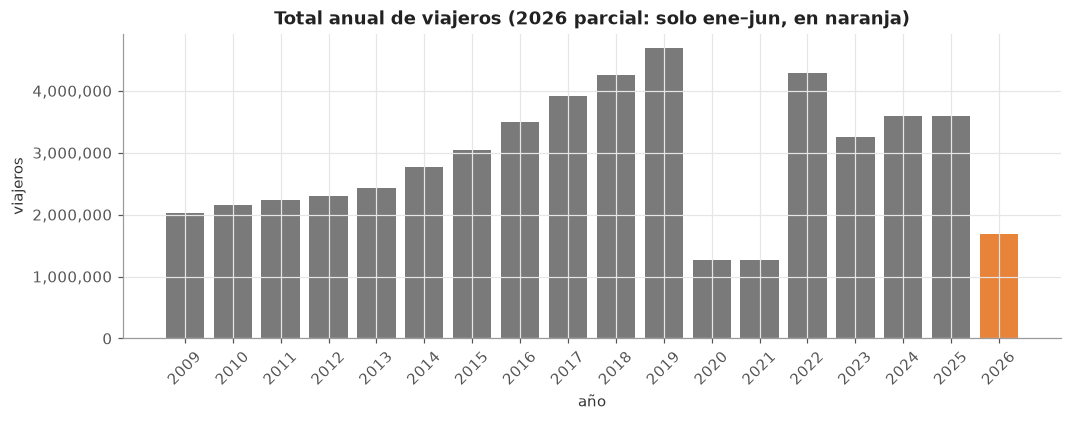

In [7]:
fig, ax = plt.subplots(figsize=(11, 3.6))
colors = [P['gris']]*len(total_anio)
# 2026 es parcial (solo hasta junio): marcarlo distinto
if 2026 in total_anio.index:
    colors[list(total_anio.index).index(2026)] = P['naranja']
ax.bar(total_anio.index.astype(str), total_anio.values, color=colors)
ax.yaxis.set_major_formatter(MILES)
ax.set_title('Total anual de viajeros (2026 parcial: solo ene–jun, en naranja)')
ax.set_xlabel('año'); ax.set_ylabel('viajeros')
plt.xticks(rotation=45); plt.savefig(config.FIG_DIR / 'eda_total_anual.png'); plt.show()

**Interpretación (temporal).** Se observa una **tendencia creciente** de 2009 a 2019, un **desplome abrupto en 2020**
por la pandemia (cierre de fronteras/aeropuerto) y una **recuperación progresiva** a partir de 2021 que retoma
—e incluso supera— los niveles prepandemia. El año **2026 es parcial** (solo enero–junio), por lo que su barra no es
comparable con años completos. La caída visible en 2023 en el total **no es una caída real de turismo**: entre 2022 y 2023
la categoría `Viajero` dejó de incluir viajeros no turísticos de alta frecuencia (tránsito/comercio fronterizo).

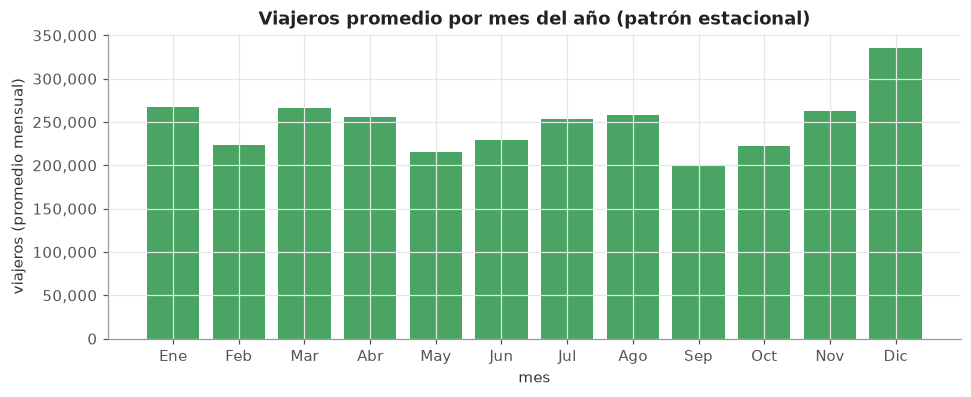

In [8]:
# Estacionalidad: viajeros promedio por mes del año (patrón intra-anual)
orden_mes = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
por_mes = (df.groupby(['Año','Mes cod'])['Viajero'].sum().reset_index()
             .groupby('Mes cod')['Viajero'].mean())
fig, ax = plt.subplots(figsize=(10, 3.6))
ax.bar([orden_mes[i-1] for i in por_mes.index], por_mes.values, color=P['verde'])
ax.yaxis.set_major_formatter(MILES)
ax.set_title('Viajeros promedio por mes del año (patrón estacional)')
ax.set_xlabel('mes'); ax.set_ylabel('viajeros (promedio mensual)')
plt.savefig(config.FIG_DIR / 'eda_estacionalidad.png'); plt.show()

**Interpretación (estacionalidad).** Aparecen **picos estacionales** en los meses de vacaciones —**marzo/abril**
(Semana Santa), **junio–julio** y **diciembre**— y valles en meses de temporada baja (septiembre). Este patrón
anual recurrente anticipa una **componente estacional de período 12** que confirmaremos en la descomposición.

### 1.4 Países con mayor cantidad de viajeros (inciso 1.b)

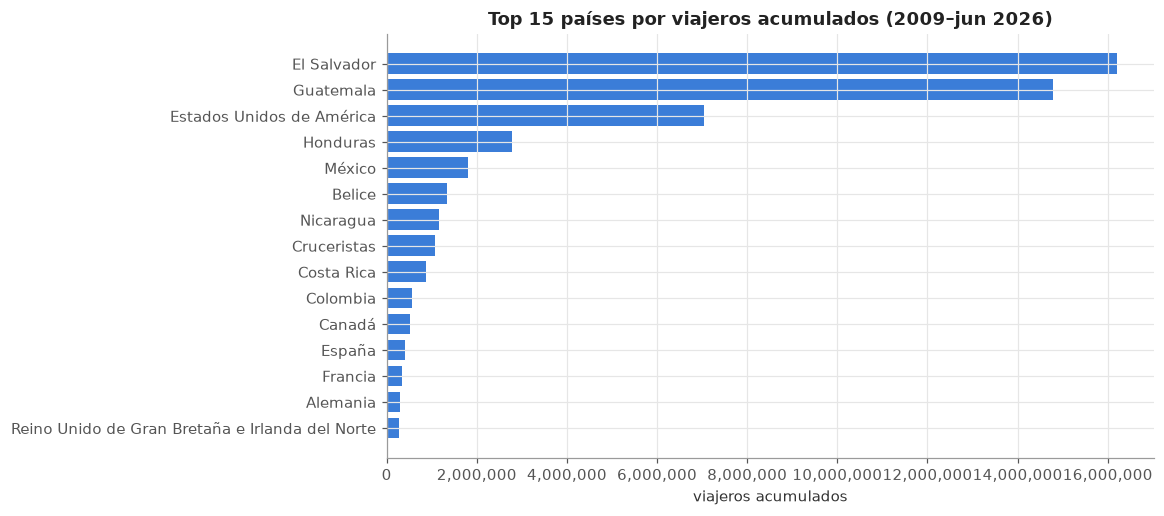

Top 3 acumulado: ['El Salvador', 'Guatemala', 'Estados Unidos de América']


In [9]:
top_pais = df.groupby('País')['Viajero'].sum().sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top_pais.index[::-1], top_pais.values[::-1], color=P['azul'])
ax.xaxis.set_major_formatter(MILES)
ax.set_title('Top 15 países por viajeros acumulados (2009–jun 2026)')
ax.set_xlabel('viajeros acumulados')
plt.savefig(config.FIG_DIR / 'eda_top_paises.png'); plt.show()
print('Top 3 acumulado:', list(top_pais.head(3).index))

**Interpretación (países).** Dominan los países **vecinos por tierra**: **El Salvador** encabeza y **Guatemala**
aparece en segundo lugar (retornos de residentes/tránsito), seguidos de **Estados Unidos** (principal mercado aéreo
de larga distancia) y **Honduras/México**. El peso de El Salvador, Guatemala y Honduras refleja el intenso
**tráfico terrestre fronterizo**, no turismo aéreo. Esta distinción es clave: el Top 3 por acumulado mezcla
tránsito con turismo real.

### 1.5 Regiones con mayor cantidad de viajeros (inciso 1.c)

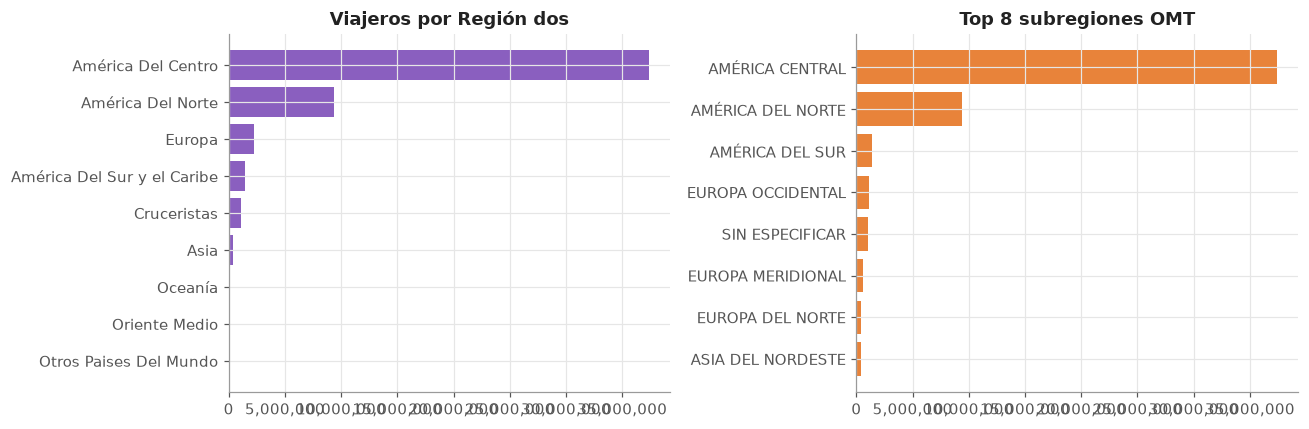

Top 3 Región dos: ['América Del Centro', 'América Del Norte', 'Europa']


In [10]:
reg2 = df.groupby('Región dos')['Viajero'].sum().sort_values(ascending=False)
omt = df.groupby('Regiones OMT')['Viajero'].sum().sort_values(ascending=False).head(8)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].barh(reg2.index[::-1], reg2.values[::-1], color=P['morado'])
ax[0].xaxis.set_major_formatter(MILES); ax[0].set_title('Viajeros por Región dos')
ax[1].barh(omt.index[::-1], omt.values[::-1], color=P['naranja'])
ax[1].xaxis.set_major_formatter(MILES); ax[1].set_title('Top 8 subregiones OMT')
plt.tight_layout(); plt.savefig(config.FIG_DIR / 'eda_regiones.png'); plt.show()
print('Top 3 Región dos:', list(reg2.head(3).index))

**Interpretación (regiones).** En `Región dos`, **América del Centro** y las Américas concentran la mayor parte del
volumen (coherente con el peso terrestre centroamericano), mientras que **Europa** aporta un flujo importante de
turismo aéreo de larga distancia. En las subregiones OMT destacan **América Central**, **América del Norte** y
**Europa Occidental/del Norte**.

### 1.6 Vías de ingreso y fronteras más utilizadas (inciso 1.d)

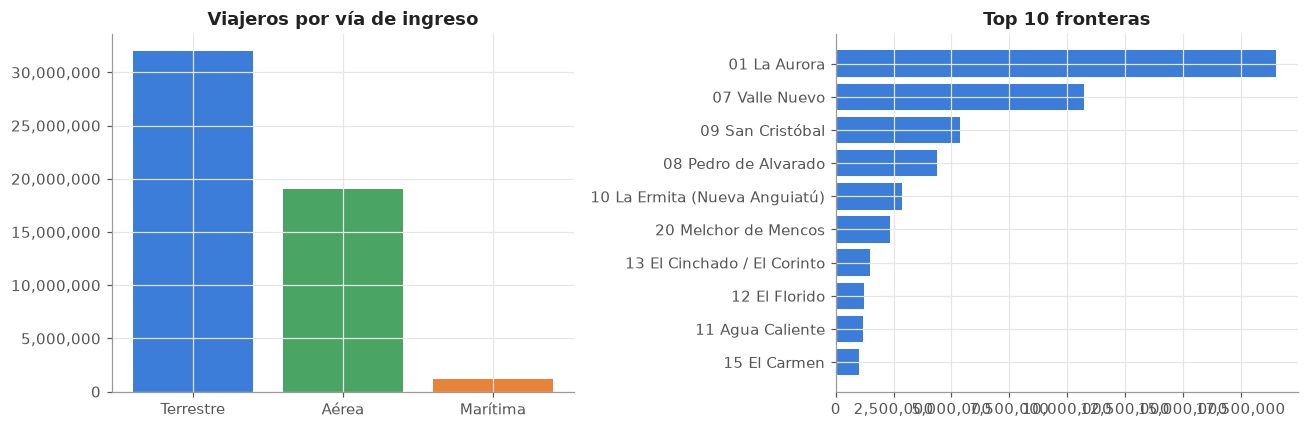

Vías: {'Terrestre': np.float64(31995231.0), 'Aérea': np.float64(19063103.0), 'Marítima': np.float64(1202752.0)}
Top 3 fronteras: ['01 La Aurora', '07 Valle Nuevo', '09 San Cristóbal']


In [11]:
via = df.groupby('Vía')['Viajero'].sum().sort_values(ascending=False)
front = df.groupby('Frontera')['Viajero'].sum().sort_values(ascending=False).head(10)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(via.index, via.values, color=[P['azul'],P['verde'],P['naranja']])
ax[0].yaxis.set_major_formatter(MILES); ax[0].set_title('Viajeros por vía de ingreso')
ax[1].barh(front.index[::-1], front.values[::-1], color=P['azul'])
ax[1].xaxis.set_major_formatter(MILES); ax[1].set_title('Top 10 fronteras')
plt.tight_layout(); plt.savefig(config.FIG_DIR / 'eda_vias_fronteras.png'); plt.show()
print('Vías:', dict(via.round(0)))
print('Top 3 fronteras:', list(front.head(3).index))

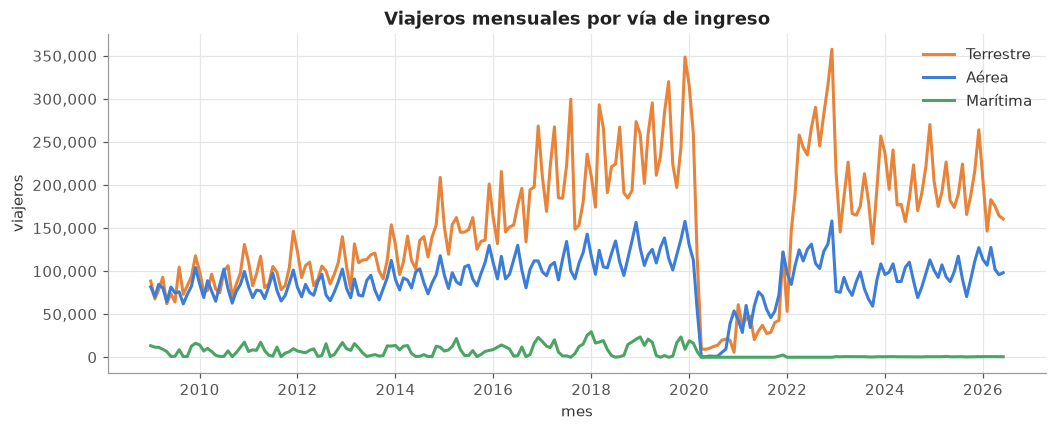

In [12]:
# Evolución de las vías en el tiempo (mix cambiante)
via_mes = df.pivot_table(index='fecha', columns='Vía', values='Viajero', aggfunc='sum').fillna(0)
fig, ax = plt.subplots(figsize=(11, 4))
for col, color in zip(['Terrestre','Aérea','Marítima'], [P['naranja'],P['azul'],P['verde']]):
    ax.plot(via_mes.index, via_mes[col], label=col, color=color)
ax.yaxis.set_major_formatter(MILES)
ax.set_title('Viajeros mensuales por vía de ingreso')
ax.set_xlabel('mes'); ax.set_ylabel('viajeros'); ax.legend()
plt.savefig(config.FIG_DIR / 'eda_vias_tiempo.png'); plt.show()

**Interpretación (vías/fronteras).** La vía **Terrestre** es la más usada por amplio margen (frontera con El Salvador:
**Valle Nuevo**, San Cristóbal, Pedro de Alvarado), seguida de la **Aérea** (**La Aurora**, la frontera individual #1)
y una **Marítima** minoritaria (cruceros). En el tiempo, la terrestre marca el volumen y su estacionalidad; la aérea
crece de forma más estable y fue la más golpeada en términos relativos durante el cierre de 2020.

### 1.7 Efecto de la definición de `Tipo de Viajero` (consistencia de la serie)

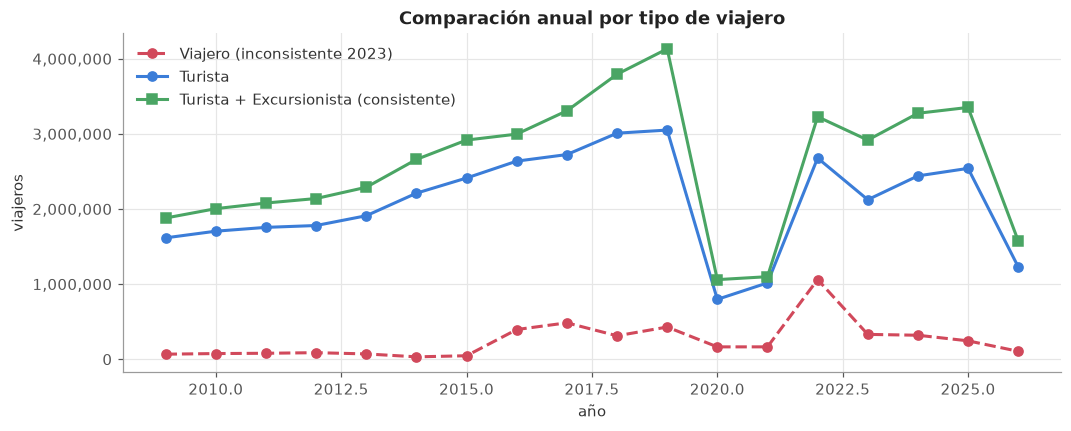

In [13]:
tipo_anio = df.pivot_table(index='Año', columns='Tipo de Viajero', values='Viajero', aggfunc='sum').fillna(0)
consistente = tipo_anio.get('Turista', 0) + tipo_anio.get('Excursionista', 0)
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(tipo_anio.index, tipo_anio.get('Viajero'), '--o', label='Viajero (inconsistente 2023)', color=P['rojo'])
ax.plot(tipo_anio.index, tipo_anio.get('Turista'), '-o', label='Turista', color=P['azul'])
ax.plot(tipo_anio.index, consistente, '-s', label='Turista + Excursionista (consistente)', color=P['verde'])
ax.yaxis.set_major_formatter(MILES)
ax.set_title('Comparación anual por tipo de viajero')
ax.set_xlabel('año'); ax.set_ylabel('viajeros'); ax.legend()
plt.savefig(config.FIG_DIR / 'eda_tipo_viajero.png'); plt.show()

**Interpretación (tipo de viajero).** La categoría `Viajero` (rojo) **se rompe en 2023** al excluir tránsito/comercio
fronterizo de alta frecuencia, generando una caída artificial. En cambio **Turista + Excursionista** (verde) es
**consistente en todo el período** y es la métrica recomendada para comparaciones de largo plazo, tal como indica el
enunciado.

## Resumen de hallazgos del EDA

1. **Datos íntegros**: 210 meses consecutivos, sin nulos ni duplicados; `Viajero` con valores fraccionarios (estimados).
2. **Tendencia + estacionalidad + shock**: crecimiento 2009–2019, desplome pandémico 2020, recuperación 2021→; picos en Semana Santa, mitad y fin de año (estacionalidad de período 12).
3. **Predominio terrestre y centroamericano**: El Salvador/Guatemala/Honduras dominan por tránsito terrestre; EE. UU. y Europa lideran el turismo aéreo de larga distancia.
4. **La Aurora** es la principal frontera individual; **Valle Nuevo** la principal terrestre.
5. **Cuidado metodológico**: la categoría `Viajero` es inconsistente desde 2023; usar `Turista + Excursionista` para comparabilidad.

Estos hallazgos motivan las series construidas en el cuaderno **02** (Total mensual, por Vía y por Tipo de viajero).